# PatentLens - Model Training v2

**What's new vs. the first pass (`01_eda.ipynb`):**

1. **Scales past 3,000 patents.** Retrieval is done one query row at a time (via `src/patentlens/retrieval.py`), never as a full n x n similarity matrix, and the embedding models use a FAISS index. That's what let the original notebook's approach handle 3,000 patents but would have made it unusably slow/memory-heavy at 10-50k+ -- it doesn't need to change as the corpus grows.
2. **A patent-specific embedding model** (`AI-Growth-Lab/PatentSBERTa`, fine-tuned on patent claims) alongside general-purpose MiniLM, to see whether domain-specific pretraining actually helps.
3. **A hybrid model** combining BM25 (lexical) with the best embedding model via Reciprocal Rank Fusion -- often beats either alone.
4. **Richer metrics.** Recall@k alone doesn't show ranking quality or tell you how much to trust a small sample. This notebook adds Precision@k, MRR, and NDCG@k, all with bootstrap confidence intervals.
5. **Saved artifacts.** Every fitted retriever gets persisted to `models/`, so the Streamlit app loads instantly instead of recomputing embeddings/indices on every run.

Set `FETCH_FROM_BIGQUERY = True` in the data-loading cell to pull a larger corpus than the
3,000-patent CSV checked into this repo -- see `src/patentlens/data_fetch.py` for the query
and a cost-estimation helper. Everything downstream works unchanged regardless of corpus size.


In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SRC_PATH = PROJECT_ROOT / "src"
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from patentlens import cleaning, retrieval, evaluation

sns.set_style("whitegrid")
pd.set_option("display.max_colwidth", 80)


## 1. Load data

By default this loads the existing `data/raw/patents_g06n3_wide.csv` (~3,000 patents). To
scale up, flip `FETCH_FROM_BIGQUERY = True` below and set your GCP `PROJECT_ID` -- it will
dry-run the query first and print the estimated cost/bytes scanned before pulling anything.


In [2]:
FETCH_FROM_BIGQUERY = False   # set True once you have a GCP project id to query with
PROJECT_ID = "your-gcp-project-id"
ROW_CAP = None                # None = pull everything BigQuery finds for the CPC prefix

RAW_CSV_PATH = PROJECT_ROOT / "data" / "raw" / "patents_g06n3_wide.csv"

if FETCH_FROM_BIGQUERY:
    from patentlens import data_fetch

    bytes_scanned, est_usd = data_fetch.estimate_query_cost(PROJECT_ID, row_cap=ROW_CAP)
    print(f"Dry run: {bytes_scanned / 1e9:.1f} GB scanned, ~${est_usd:.2f} estimated cost")
    print("Re-run this cell with FETCH_FROM_BIGQUERY left True only once you're happy with that estimate.")

    df = data_fetch.fetch_patents(PROJECT_ID, row_cap=ROW_CAP)
    df.to_csv(RAW_CSV_PATH, index=False)
    print(f"Saved {len(df)} rows to {RAW_CSV_PATH}")
else:
    df = pd.read_csv(RAW_CSV_PATH)

print("Loaded shape:", df.shape)
df.head(3)


Loaded shape: (3000, 7)


,publication_number,filing_date,publication_date,title,abstract,cpc_codes,cited_patents
0,US-2024119857-A1,20220927,20240411,Systems and methods for training a scene simulator using real and simulated ...,"System, methods, and other embodiments described herein relate to training a...",G06N3/0442|G06N3/0464|G06N3/096|G06N3/092|G06N3/045|G06N3/006,US-2016314224-A1|US-2018275658-A1|US-2019094875-A1|US-2019228571-A1|US-20203...
1,US-2023182019-A1,20230209,20230615,Multimodal experience modeling for gaming applications,A system operates by generating BEA tools that include an AI model trained v...,G06N3/047|G06N3/048|G06N3/045|G06N3/08|G06N3/006|G06N3/092|G06N3/0464|G06N3/09,NaN
2,US-2021216862-A1,20200115,20210715,System and method for semantic analysis of multimedia data using attention-b...,A system and a method for multimedia data analysis. The system includes a co...,G06N3/08|G06N3/045|G06N3/045|G06N3/044|G06N3/0455|G06N3/0464|G06N3/09|G06N3/...,NaN


## 2. Clean text and derive features

In [3]:
df = cleaning.prepare_dataframe(df)

print(df['clean_word_count'].describe())
print("\nRows with fewer than 10 words after cleaning:", (df['clean_word_count'] < 10).sum())
df[['publication_number', 'title', 'clean_word_count', 'primary_cpc_class']].head(3)


count    3000.000000
mean       66.624333
std        19.317650
min        12.000000
25%        53.000000
50%        67.000000
75%        80.000000
max       201.000000
Name: clean_word_count, dtype: float64

Rows with fewer than 10 words after cleaning: 0


,publication_number,title,clean_word_count,primary_cpc_class
0,US-2024119857-A1,Systems and methods for training a scene simulator using real and simulated ...,52,G06N
1,US-2023182019-A1,Multimodal experience modeling for gaming applications,77,G06N
2,US-2021216862-A1,System and method for semantic analysis of multimedia data using attention-b...,91,G06N


## 3. Build citation ground truth

Same idea as the original notebook: a patent's real citations, restricted to whichever cited
patents also fall inside our sampled corpus, become the evaluation ground truth for retrieval
quality. This coverage number should climb as the corpus grows, which makes every metric below
less noisy than it was on 3,000 patents.


In [4]:
ground_truth, pub_to_idx = evaluation.build_ground_truth(df)

n_queries = len(ground_truth)
n_pairs = sum(len(v) for v in ground_truth.values())
print(f"Query patents with >=1 in-sample citation: {n_queries} / {len(df)} ({n_queries/len(df):.1%})")
print(f"Total usable citation pairs: {n_pairs}")


Query patents with >=1 in-sample citation: 127 / 3000 (4.2%)
Total usable citation pairs: 147


## 4. Build retrievers

Each retriever is fit once on `df['clean_text']` and exposes `.rank(query_idx, top_k)` for
evaluation and `.rank_text(free_text, top_k)` for live search in the Streamlit app.


In [5]:
tfidf = retrieval.TfidfRetriever().fit(df['clean_text'])
print("TF-IDF matrix shape:", tfidf.matrix.shape)


TF-IDF matrix shape: (3000, 5000)


In [6]:
bm25 = retrieval.Bm25Retriever().fit(df['clean_text'])
print("BM25 fit on", len(bm25.tokenized_corpus), "documents")


BM25 fit on 3000 documents


In [7]:
lsa = retrieval.LsaRetriever(tfidf, n_components=100).fit()
print("LSA matrix shape:", lsa.lsa_matrix.shape)
print("Variance explained:", round(lsa.svd.explained_variance_ratio_.sum(), 4))


LSA matrix shape: (3000, 100)
Variance explained: 0.2424


In [8]:
minilm = retrieval.EmbeddingRetriever(model_name="all-MiniLM-L6-v2", name="MiniLM").fit(df['clean_text'])
print("MiniLM embeddings shape:", minilm.embeddings.shape)


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

C:\Users\katte\PatentLens\PatentLens\venv\Lib\site-packages\huggingface_hub\file_download.py:137: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\katte\.cache\huggingface\hub\models--sentence-transformers--all-MiniLM-L6-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/94 [00:00<?, ?it/s]

MiniLM embeddings shape: (3000, 384)


In [9]:
patentsberta = retrieval.EmbeddingRetriever(
    model_name="AI-Growth-Lab/PatentSBERTa", name="PatentSBERTa"
).fit(df['clean_text'])
print("PatentSBERTa embeddings shape:", patentsberta.embeddings.shape)


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

C:\Users\katte\PatentLens\PatentLens\venv\Lib\site-packages\huggingface_hub\file_download.py:137: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\katte\.cache\huggingface\hub\models--AI-Growth-Lab--PatentSBERTa. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/3.88k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/94 [00:00<?, ?it/s]

PatentSBERTa embeddings shape: (3000, 768)


## 5. Hybrid model (BM25 + best embedding model, via Reciprocal Rank Fusion)

Lexical and semantic retrieval tend to make different mistakes, so fusing their rankings
(rather than picking one) is a common way to pick up both keyword-exact-match cases (BM25's
strength) and paraphrased/semantically-related cases (PatentSBERTa's strength).


In [10]:
hybrid = retrieval.HybridRetriever([bm25, patentsberta], weights=[1.0, 1.0], name="Hybrid (BM25 + PatentSBERTa)")


## 6. Evaluate every model

In [11]:
retrievers = {
    "TF-IDF": tfidf,
    "BM25": bm25,
    "LSA": lsa,
    "MiniLM": minilm,
    "PatentSBERTa": patentsberta,
    "Hybrid (BM25 + PatentSBERTa)": hybrid,
}

K_VALUES = (5, 10, 20)
all_summaries = {}
all_per_query = {}

for name, retriever in retrievers.items():
    rank_fn = lambda q, k, r=retriever: r.rank(q, top_k=k)[0]
    summary, per_query = evaluation.evaluate_retriever(rank_fn, ground_truth, k_values=K_VALUES)
    all_summaries[name] = summary
    all_per_query[name] = per_query
    print(f"{name}: MRR={summary['MRR']['mean']:.4f}  Recall@10={summary['Recall@10']['mean']:.4f}  NDCG@10={summary['NDCG@10']['mean']:.4f}")


TF-IDF: MRR=0.1529  Recall@10=0.2165  NDCG@10=0.1596


BM25: MRR=0.1800  Recall@10=0.2572  NDCG@10=0.1890


LSA: MRR=0.1445  Recall@10=0.1877  NDCG@10=0.1463
MiniLM: MRR=0.1715  Recall@10=0.2598  NDCG@10=0.1810


PatentSBERTa: MRR=0.1257  Recall@10=0.1850  NDCG@10=0.1319


Hybrid (BM25 + PatentSBERTa): MRR=0.1762  Recall@10=0.2546  NDCG@10=0.1870


## 7. Results comparison

In [12]:
summary_df = evaluation.summary_to_dataframe(all_summaries)
pivot = summary_df.pivot(index='model', columns='metric', values='mean')
metric_order = [f'{m}@{k}' for m in ['Recall', 'Precision', 'NDCG'] for k in K_VALUES] + ['MRR']
pivot = pivot[[c for c in metric_order if c in pivot.columns]].round(4)
pivot


metric,Recall@5,Recall@10,Recall@20,Precision@5,Precision@10,Precision@20,NDCG@5,NDCG@10,NDCG@20,MRR
model,,,,,,,,,,
BM25,0.1837,0.2572,0.2730,0.0425,0.0291,0.0154,0.1657,0.1890,0.1930,0.1800
Hybrid (BM25 + PatentSBERTa),0.2087,0.2546,0.3123,0.0457,0.0283,0.0173,0.1720,0.1870,0.2022,0.1762
LSA,0.1640,0.1877,0.2178,0.0378,0.0213,0.0126,0.1382,0.1463,0.1548,0.1445
MiniLM,0.1969,0.2598,0.3176,0.0441,0.0283,0.0177,0.1610,0.1810,0.1966,0.1715
PatentSBERTa,0.1535,0.1850,0.2480,0.0346,0.0205,0.0138,0.1216,0.1319,0.1484,0.1257
TF-IDF,0.1745,0.2165,0.2638,0.0425,0.0260,0.0154,0.1452,0.1596,0.1716,0.1529


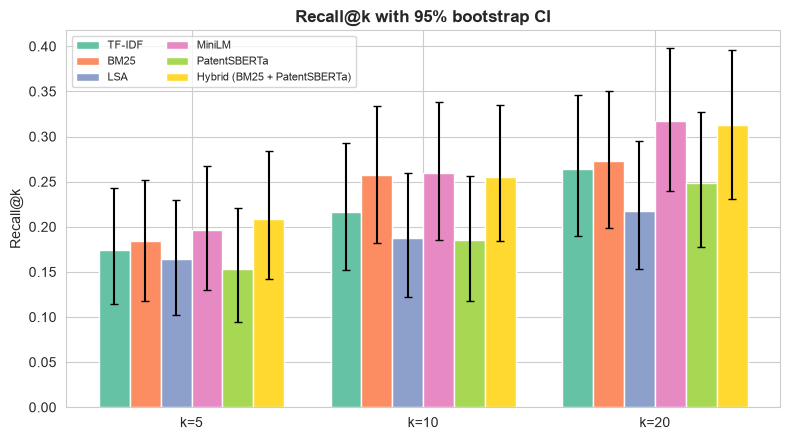

In [13]:
def plot_metric_with_ci(summary_df, metric_prefix, k_values, title):
    fig, ax = plt.subplots(figsize=(8, 4.5))
    models = list(summary_df['model'].unique())
    colors = sns.color_palette("Set2", len(models))
    x = np.arange(len(k_values))
    width = 0.8 / len(models)

    for i, model in enumerate(models):
        means, los, his = [], [], []
        for k in k_values:
            row = summary_df[(summary_df['model'] == model) & (summary_df['metric'] == f'{metric_prefix}@{k}')].iloc[0]
            means.append(row['mean'])
            los.append(row['mean'] - row['ci_low'])
            his.append(row['ci_high'] - row['mean'])
        ax.bar(x + i * width, means, width, label=model, color=colors[i],
               yerr=[los, his], capsize=3)

    ax.set_xticks(x + width * (len(models) - 1) / 2)
    ax.set_xticklabels([f'k={k}' for k in k_values])
    ax.set_ylabel(f"{metric_prefix}@k")
    ax.set_title(title, fontweight='bold')
    ax.legend(loc='upper left', fontsize=8, ncol=2)
    plt.tight_layout()
    return fig

fig1 = plot_metric_with_ci(summary_df, 'Recall', K_VALUES, "Recall@k with 95% bootstrap CI")
plt.savefig(PROJECT_ROOT / "outputs" / "recall_comparison.png", dpi=150)
plt.show()


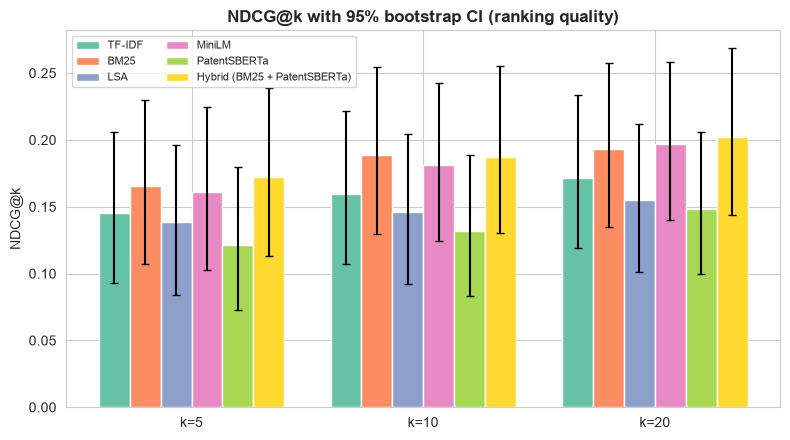

In [14]:
fig2 = plot_metric_with_ci(summary_df, 'NDCG', K_VALUES, "NDCG@k with 95% bootstrap CI (ranking quality)")
plt.savefig(PROJECT_ROOT / "outputs" / "ndcg_comparison.png", dpi=150)
plt.show()


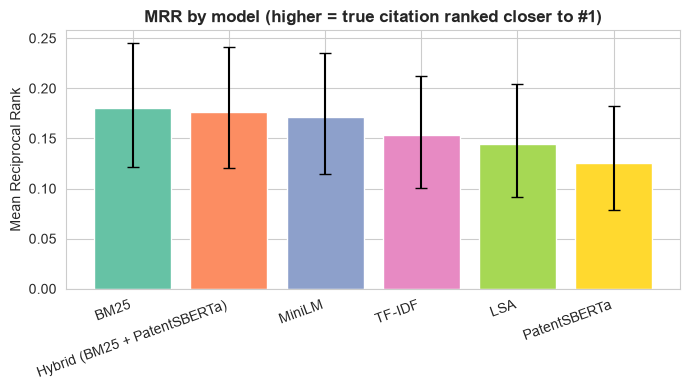

In [15]:
mrr_df = summary_df[summary_df['metric'] == 'MRR'].sort_values('mean', ascending=False)
fig, ax = plt.subplots(figsize=(7, 4))
colors = sns.color_palette("Set2", len(mrr_df))
bars = ax.bar(mrr_df['model'], mrr_df['mean'],
              yerr=[mrr_df['mean'] - mrr_df['ci_low'], mrr_df['ci_high'] - mrr_df['mean']],
              capsize=4, color=colors)
ax.set_ylabel("Mean Reciprocal Rank")
ax.set_title("MRR by model (higher = true citation ranked closer to #1)", fontweight='bold')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "outputs" / "mrr_comparison.png", dpi=150)
plt.show()


## 8. Qualitative sanity check

Numbers aside, spot-check that the top model's neighbors actually look related -- useful
both as a sanity check and as material for the live demo.


In [16]:
best_model_name = mrr_df.iloc[0]['model']
best_retriever = retrievers[best_model_name]
print("Best model by MRR:", best_model_name)

test_idx = 0
idxs, scores = best_retriever.rank(test_idx, top_k=5)
print("\nQuery patent:", df.iloc[test_idx]['publication_number'], "-", df.iloc[test_idx]['title'])
print("\nTop 5 similar patents:")
pd.DataFrame({
    'publication_number': df.iloc[idxs]['publication_number'].values,
    'title': df.iloc[idxs]['title'].values,
    'score': np.round(scores, 4),
})


Best model by MRR: BM25

Query patent: US-2024119857-A1 - Systems and methods for training a scene simulator using real and simulated agent data

Top 5 similar patents:


,publication_number,title,score
0,US-2024221312-A1,Systems and methods for generating and/or using 3-dimensional information wi...,106.6562
1,US-11288884-B2,UAV real-time path planning method for urban scene reconstruction,93.7877
2,US-2024135197-A1,Generating enriched scenes using scene graphs,88.8636
3,US-2023041501-A1,Policy neural network training using a privileged expert policy,86.1482
4,US-2019258907-A1,Scene understanding and generation using neural networks,83.7139


## 9. Save artifacts for the Streamlit app

Everything the app needs to run without recomputing: the cleaned dataframe, every fitted
retriever, and the metrics summary (for the in-app comparison tab).


In [17]:
import joblib

MODELS_DIR = PROJECT_ROOT / "models"
MODELS_DIR.mkdir(exist_ok=True)

df.to_parquet(MODELS_DIR / "patents.parquet")

tfidf.save(MODELS_DIR / "tfidf.joblib")
bm25.save(MODELS_DIR / "bm25.joblib")
lsa.save(MODELS_DIR / "lsa.joblib")
minilm.save(MODELS_DIR / "minilm")
patentsberta.save(MODELS_DIR / "patentsberta")

summary_df.to_csv(MODELS_DIR / "metrics_summary.csv", index=False)
pivot.to_csv(MODELS_DIR / "metrics_pivot.csv")

print("Saved artifacts to", MODELS_DIR)
for p in sorted(MODELS_DIR.rglob("*")):
    if p.is_file():
        print(" ", p.relative_to(MODELS_DIR))


Saved artifacts to C:\Users\katte\PatentLens\PatentLens\models
  bm25.joblib
  lsa.joblib
  metrics_pivot.csv
  metrics_summary.csv
  minilm\embeddings.npy
  minilm\index.faiss
  minilm\meta.joblib
  patents.parquet
  patentsberta\embeddings.npy
  patentsberta\index.faiss
  patentsberta\meta.joblib
  tfidf.joblib
